### [GitHub](https://github.com/msultanmahmud/Stress_WESAD/blob/master/Multiclass_Pipeline_Individual_sub_INTEC.ipynb)

In [ ]:
# ! pip list

In [ ]:
# ! pip install lightgbm

In [1]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics,preprocessing
#from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt
from collections import Counter
from scipy.stats import norm
import seaborn as sns; sns.set(font_scale=1.2)
%matplotlib inline
import time
import xgboost as xgb
import lightgbm as lgb

#### Redaing file

In [6]:
df=pd.read_csv('../dreamt_preprocessed.csv')
df.subject.nunique()

100

In [8]:
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]

# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df.head(5) 

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625


### Drop subject those who have some data Msisning 

In [11]:
df = df[~df['subject'].isin(['S062', 'S097'])]
pre_procss_all=df.copy()
pre_procss_all

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


In [13]:
## >>>>>> PPG DATA Separation done <<<<<<<<<<<<

In [15]:
wanted_keywords = ['subject','epoch','BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI','label']
pattern = '|'.join(wanted_keywords)  # Creates 'BVP|EDA|TEMP|ACC_X|ACC_Y|ACC_Z|HR|IBI'

# Select matching columns
df_ppg = pre_procss_all.filter(regex=pattern, axis=1)
df_ppg
# Drop columns with any null (NaN) values
df_ppg_cleaned = df_ppg.dropna(axis=1, how='any')

# Optionally: print removed columns
ppg_removed_cols = df_ppg.columns[df_ppg.isnull().any()].tolist()
print("Removed columns with nulls:", ppg_removed_cols)

df_ppg_cleaned = df_ppg_cleaned[df_ppg_cleaned['label'].isin([0,1,2])]
df_ppg_cleaned.head(3)

Removed columns with nulls: []


,subject,epoch,label,BVP_min,BVP_max,BVP_mean,BVP_std,BVP_p5,BVP_p25,BVP_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
305,S002,307,0.0,-1257.38,705.59,0.654393,172.768194,-327.953,-16.4275,4.025,...,81.62,0.937500,0.953125,0.952734,0.002440,0.953125,0.953125,0.953125,0.953125,0.953125
306,S002,308,0.0,-749.06,472.29,-0.381060,101.202434,-95.095,-22.2800,1.430,...,85.00,0.953125,0.953125,0.953125,0.000000,0.953125,0.953125,0.953125,0.953125,0.953125
307,S002,309,0.0,-281.51,153.36,-1.509670,58.567645,-114.200,-24.3425,2.820,...,82.45,0.812500,0.953125,0.823187,0.037272,0.812500,0.812500,0.812500,0.812500,0.953125


In [17]:
### How many subjec
sample=df_ppg_cleaned.subject.unique()[:15]
# # Sample the data (if needed)
df_sample = df_ppg_cleaned[df_ppg_cleaned.subject.isin(sample)]
df_sample

,subject,epoch,label,BVP_min,BVP_max,BVP_mean,BVP_std,BVP_p5,BVP_p25,BVP_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
305,S002,307,0.0,-1257.38,705.59,0.654393,172.768194,-327.9530,-16.4275,4.025,...,81.62,0.937500,0.953125,0.952734,0.002440,0.953125,0.953125,0.953125,0.953125,0.953125
306,S002,308,0.0,-749.06,472.29,-0.381060,101.202434,-95.0950,-22.2800,1.430,...,85.00,0.953125,0.953125,0.953125,0.000000,0.953125,0.953125,0.953125,0.953125,0.953125
307,S002,309,0.0,-281.51,153.36,-1.509670,58.567645,-114.2000,-24.3425,2.820,...,82.45,0.812500,0.953125,0.823187,0.037272,0.812500,0.812500,0.812500,0.812500,0.953125
308,S002,310,0.0,-369.24,242.02,1.410377,74.185047,-126.8245,-37.6350,6.530,...,85.88,0.812500,0.812500,0.812500,0.000000,0.812500,0.812500,0.812500,0.812500,0.812500
309,S002,311,0.0,-572.48,620.29,-0.499120,154.295774,-286.6220,-42.6350,1.215,...,87.73,0.765625,0.968750,0.781552,0.046296,0.765625,0.765625,0.765625,0.765625,0.953125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14155,S016,1065,1.0,-61.68,24.59,-0.114220,11.258042,-19.5825,-8.0125,1.990,...,61.35,0.859375,1.187500,0.972151,0.091068,0.875000,0.875000,1.031250,1.046875,1.046875
14156,S016,1067,2.0,-88.42,79.15,0.037607,15.819847,-23.0700,-9.8125,2.380,...,59.03,0.812500,1.125000,1.024130,0.133572,0.812500,0.890625,1.125000,1.125000,1.125000
14157,S016,1068,2.0,-1175.42,373.21,-0.067160,103.268709,-79.5415,-12.3200,3.270,...,59.35,0.906250,1.140625,1.030818,0.101451,0.921875,0.937500,0.953125,1.140625,1.140625
14158,S016,1069,2.0,-41.39,48.49,0.096400,18.256535,-31.0500,-14.7825,3.210,...,59.02,0.828125,1.281250,1.099229,0.168746,0.937500,0.937500,0.984375,1.281250,1.281250


In [14]:
# df1=df_fusion_cleaned.copy()
# df1.head(3)

## Reading the stability score pickle that was save during the satability selection analysis

In [19]:
# with open("results_ss_v1.pkl", "rb") as f:
with open("stability_score_alpha_ppg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [21]:
# # Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]

# # Filter the dictionary
# results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
# results_filtered
# import pickle
# with open("stability_score_alpha_whole_v1.pkl", "wb") as f:
#     pickle.dump(results_filtered, f)


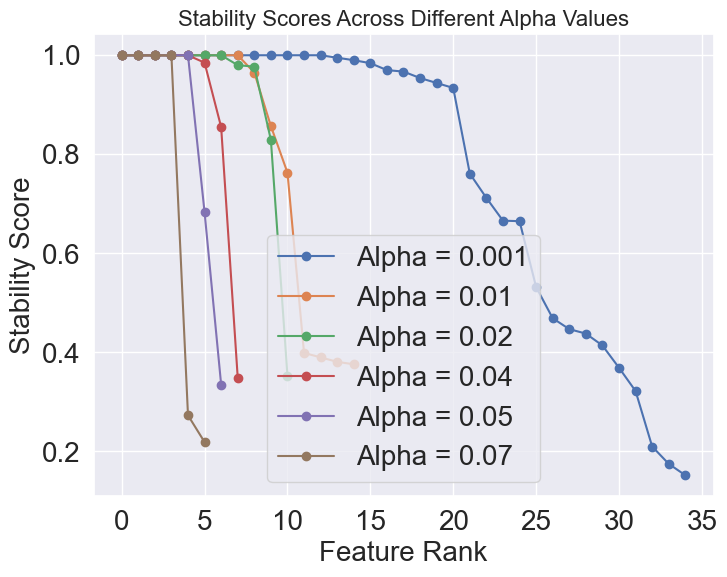

In [23]:
# Plot stability scores for each alpha
fs=20
plt.figure(figsize=(8, 6))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=fs)
plt.ylabel('Stability Score',fontsize=fs)
plt.xticks(fontsize=fs)  # Make x-axis tick labels larger
plt.yticks(fontsize=fs)  # Make y-axis tick labels larger
plt.legend(fontsize=fs,loc='lower center')
plt.grid(True)
plt.show()

In [25]:
feature_importance_df_07=results[0.07][results[0.07].Stability_Score>=0.7]['Feature'].values
sel_col=np.append(feature_importance_df_07,'label')
### Selected features only
df1=df_sample[sel_col]
df1.head(3)

,BVP_min,ACC_Z_std,ACC_Y_std,ACC_X_std,label
305,-1257.38,3.365642,1.279327,3.628029,0.0
306,-749.06,2.256455,0.455387,1.299924,0.0
307,-281.51,1.113902,0.268644,0.837405,0.0


In [27]:
#   df_sample.subject.nunique()

### Classification based on the selected Features

In [31]:
# !jupyter kernelspec list

In [33]:
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import pandas as pd
import numpy as np

def preprocess_scaling(df):
    '''Scales features and splits into train/test.'''
    X = df.drop(columns=['label'])
    y = df['label']
    X_scaled = preprocessing.scale(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # AUC calculation — multi-class
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None  # SVM without probability=True will not support this

        return (model_name, acc, f1, precision, recall, auc)
    except Exception as e:
        print(f"Error with model {model_name}: {e}")
        return (model_name, None, None, None, None, None)

def multiple_model(df, auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)
    model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']

    # SVM needs probability=True for predict_proba
    models = [
        KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2),
        DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50),
        xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), random_state=42,
                          max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                          min_child_weight=1, eval_metric='mlogloss', n_jobs=-1),
        lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                           min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1),
        RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1),
        svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=True)  # Required for AUC
    ]

    results_list = Parallel(n_jobs=-1)(delayed(train_and_evaluate)(
        model, X_train, y_train, X_test, y_test, name, auc_mode
    ) for model, name in zip(models, model_name_list))

    results_df = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC'])
    results_df.set_index('Model', inplace=True)
    results_df=results_df[['Accuracy','AUC','Precision', 'Recall','F1']]
    return results_df

### Ensemble Learning

In [36]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

def ensemble_model(df, voting_type='hard', auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)

    # Define base models
    knn = KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2)
    dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50)
    xgb_model = xgb.XGBClassifier(objective='multi:softprob', random_state=42, min_child_weight=1,
                                  max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                                  eval_metric='mlogloss', n_jobs=-1, use_label_encoder=False)
    lgb_model = lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                                   min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1)
    rf = RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1)
    svc = svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=(voting_type == 'soft'))

    # Create ensemble using voting
    ensemble = VotingClassifier(
        estimators=[
            ('KNN', knn),
            ('DT', dt),
            ('XGB', xgb_model),
            ('LGBM', lgb_model),
            ('RF', rf),
            ('SVM', svc)
        ],
        voting=voting_type,
        n_jobs=-1
    )

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Compute AUC only if voting_type is 'soft'
    try:
        if voting_type == 'soft':
            y_probs = ensemble.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None
    except Exception as e:
        print(f"AUC error: {e}")
        auc = None

    results = pd.DataFrame([{
        'Model': f'VotingClassifier ({voting_type})',
        'Accuracy': acc,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1

    }]).set_index('Model')

    return results

##Clssification based on the differnt satbility scores and alpha
- need tio cahge the stability score 'sc' 0.9,0.8.,0.7,0.6,0.5

## At stability score 0.9

### Regular classifier

In [41]:
### sc is the stability scores
sc = 0.9
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 22


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.831418,0.888028,0.775461,0.775252,0.775154
DT,0.834291,0.834428,0.782151,0.784993,0.783367
XGBoost,0.899425,0.975427,0.896244,0.847678,0.869948
LightGBM,0.906130,0.975649,0.896446,0.869698,0.882452
RF,0.897510,0.971156,0.904304,0.833500,0.864489
SVM,0.829023,0.927083,0.805407,0.731111,0.762027


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.831418,0.891139,0.775461,0.775252,0.775154
DT,0.837165,0.836935,0.787003,0.782580,0.784477
XGBoost,0.899425,0.977656,0.896244,0.847678,0.869948
LightGBM,0.906130,0.977962,0.896446,0.869698,0.882452
RF,0.895594,0.974755,0.905276,0.830430,0.863077
SVM,0.829023,0.931389,0.805407,0.731111,0.762027


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.9: 10


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.803640,0.867243,0.739636,0.749687,0.744344
DT,0.772031,0.766923,0.697973,0.693970,0.695909
XGBoost,0.857280,0.953137,0.852484,0.778678,0.810124
LightGBM,0.868295,0.952738,0.856875,0.805071,0.828431
RF,0.847222,0.944106,0.853624,0.744047,0.786929
SVM,0.741379,0.837848,0.704650,0.537425,0.579701


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.647989,0.680234,0.516811,0.518027,0.517407
DT,0.636494,0.628653,0.501882,0.504870,0.503227
XGBoost,0.727490,0.785155,0.671313,0.520690,0.557703
LightGBM,0.721743,0.789390,0.638925,0.543808,0.574548
RF,0.728927,0.793603,0.674494,0.520800,0.557931
SVM,0.707854,0.642905,0.518208,0.406012,0.396119


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.9: 5


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.687261,0.723251,0.572411,0.575582,0.573600
DT,0.638410,0.636129,0.510366,0.516234,0.513132
XGBoost,0.710728,0.745184,0.631107,0.487568,0.516683
LightGBM,0.716954,0.781475,0.629428,0.541983,0.570969
RF,0.737548,0.805297,0.695496,0.552627,0.593478
SVM,0.708333,0.633654,0.473576,0.405679,0.393921


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.687261,0.724552,0.572411,0.575582,0.573600
DT,0.645594,0.641900,0.520238,0.522534,0.521329
XGBoost,0.710728,0.745314,0.631107,0.487568,0.516683
LightGBM,0.716954,0.784218,0.629428,0.541983,0.570969
RF,0.735153,0.807550,0.687750,0.554139,0.593181
SVM,0.708333,0.646883,0.473576,0.405679,0.393921


No features was selected


In [42]:
cls_reg_ovr

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.687261,0.723251,0.572411,0.575582,0.573600
DT,0.638410,0.636129,0.510366,0.516234,0.513132
XGBoost,0.710728,0.745184,0.631107,0.487568,0.516683
LightGBM,0.716954,0.781475,0.629428,0.541983,0.570969
RF,0.737548,0.805297,0.695496,0.552627,0.593478
SVM,0.708333,0.633654,0.473576,0.405679,0.393921


##### Ensemble

In [44]:
# res_en=ensemble_model(df1, voting_type='hard')
# res_en

## Voting Ensample calssifer

In [46]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

Voting Ensample with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 22


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.904693,0.971961,0.895327,0.860696,0.876983


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.903257,0.975454,0.892516,0.859987,0.875339


0.01
Number of faetures aplha: 0.01, and ss 0.9: 10


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.730843,0.791641,0.675329,0.517526,0.555061


0.07
Number of faetures aplha: 0.07, and ss 0.9: 5


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.738506,0.795759,0.698666,0.539389,0.580942


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.735632,0.79709,0.689,0.536355,0.57648


In [47]:
ens_res_all.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

### At stability score 0.8

In [49]:
### sc is the stability scores
sc = 0.8
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.8
0.001
Number of faetures aplha: 0.001, and ss 0.8: 22


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.831418,0.888028,0.775461,0.775252,0.775154
DT,0.835249,0.834289,0.777779,0.782682,0.779812
XGBoost,0.899425,0.975427,0.896244,0.847678,0.869948
LightGBM,0.906130,0.975649,0.896446,0.869698,0.882452
RF,0.896552,0.972047,0.905354,0.832579,0.864511
SVM,0.829023,0.926948,0.805407,0.731111,0.762027


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.831418,0.891139,0.775461,0.775252,0.775154
DT,0.837644,0.839492,0.786080,0.785989,0.785968
XGBoost,0.899425,0.977656,0.896244,0.847678,0.869948
LightGBM,0.906130,0.977962,0.896446,0.869698,0.882452
RF,0.894157,0.975387,0.905263,0.827535,0.861238
SVM,0.829023,0.931326,0.805407,0.731111,0.762027


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.8: 11


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.843391,0.892649,0.793284,0.791459,0.792353
DT,0.824713,0.821437,0.771679,0.765206,0.768232
XGBoost,0.899904,0.969754,0.896163,0.850548,0.871336
LightGBM,0.905172,0.970991,0.897483,0.863596,0.879319
RF,0.884100,0.963162,0.886706,0.809817,0.842552
SVM,0.786877,0.885681,0.754891,0.626877,0.669595


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.647989,0.680234,0.516811,0.518027,0.517407
DT,0.635536,0.624167,0.498303,0.498889,0.498545
XGBoost,0.727490,0.785155,0.671313,0.520690,0.557703
LightGBM,0.721743,0.789390,0.638925,0.543808,0.574548
RF,0.725096,0.792836,0.669617,0.518400,0.555149
SVM,0.707854,0.643467,0.518208,0.406012,0.396119


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.8: 5


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.687261,0.723251,0.572411,0.575582,0.573600
DT,0.642720,0.639769,0.517986,0.522193,0.520022
XGBoost,0.710728,0.745184,0.631107,0.487568,0.516683
LightGBM,0.716954,0.781475,0.629428,0.541983,0.570969
RF,0.733238,0.807570,0.685888,0.548823,0.588175
SVM,0.708333,0.633510,0.473576,0.405679,0.393921


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.687261,0.724552,0.572411,0.575582,0.573600
DT,0.640326,0.639973,0.512726,0.519963,0.516018
XGBoost,0.710728,0.745314,0.631107,0.487568,0.516683
LightGBM,0.716954,0.784218,0.629428,0.541983,0.570969
RF,0.738027,0.807701,0.689866,0.557204,0.596484
SVM,0.708333,0.646452,0.473576,0.405679,0.393921


No features was selected


In [50]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

Voting Ensample with stability score :0.8
0.001
Number of faetures aplha: 0.001, and ss 0.8: 22


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.904215,0.972554,0.89825,0.858843,0.877228


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.902778,0.97553,0.893492,0.857026,0.874114


0.01
Number of faetures aplha: 0.01, and ss 0.8: 11


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.734195,0.790049,0.686048,0.524689,0.56397


0.07
Number of faetures aplha: 0.07, and ss 0.8: 5


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.737548,0.794014,0.695714,0.535145,0.576295


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.739464,0.794441,0.703913,0.538216,0.580487


### Ploting Fetaures

Number of Salient Features :10


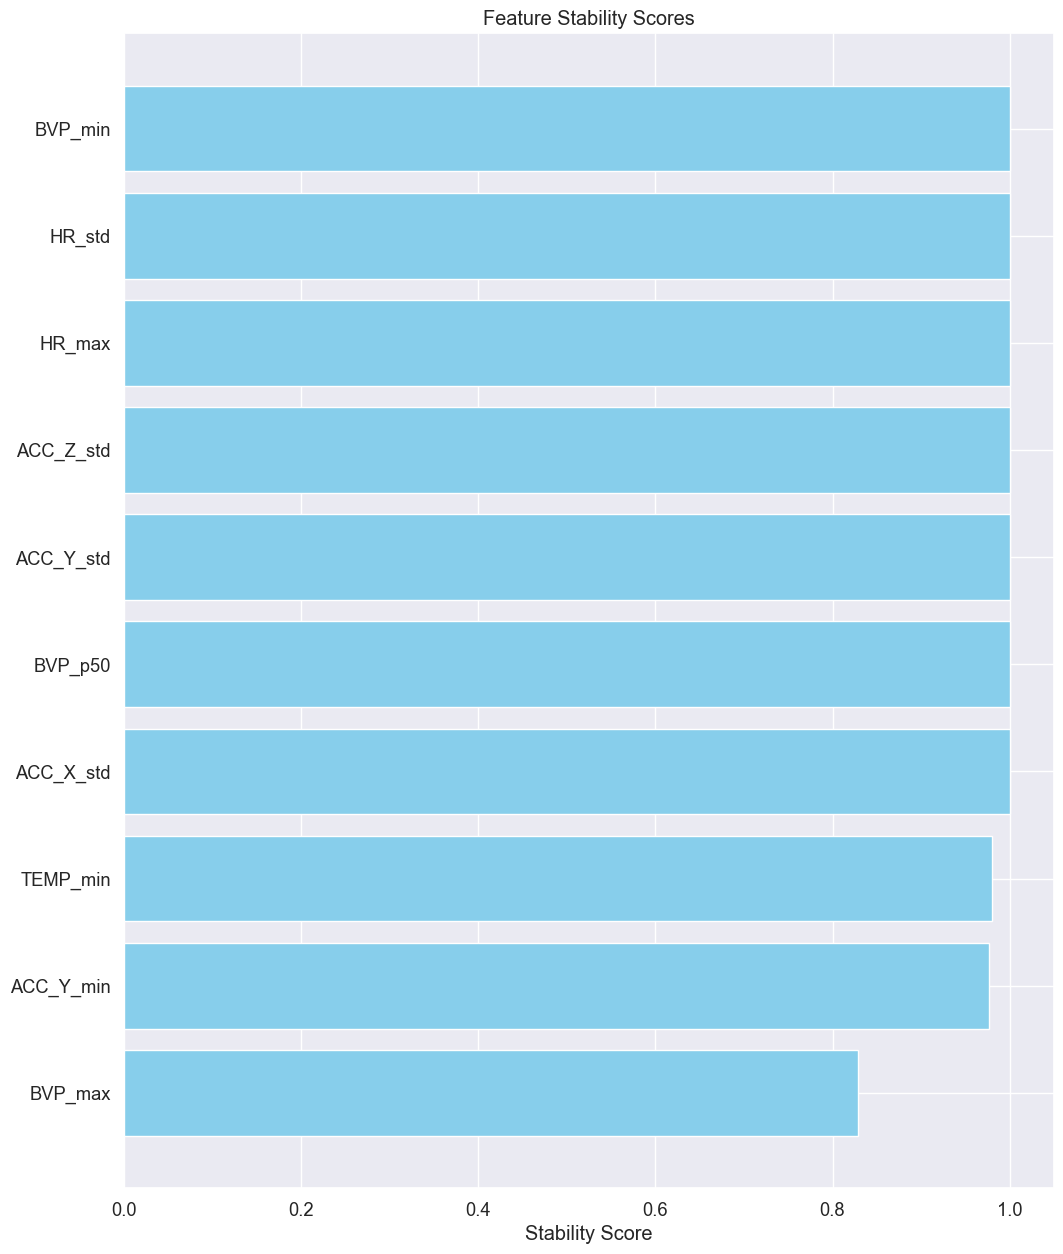

In [56]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.02;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

Number of Salient Features :10


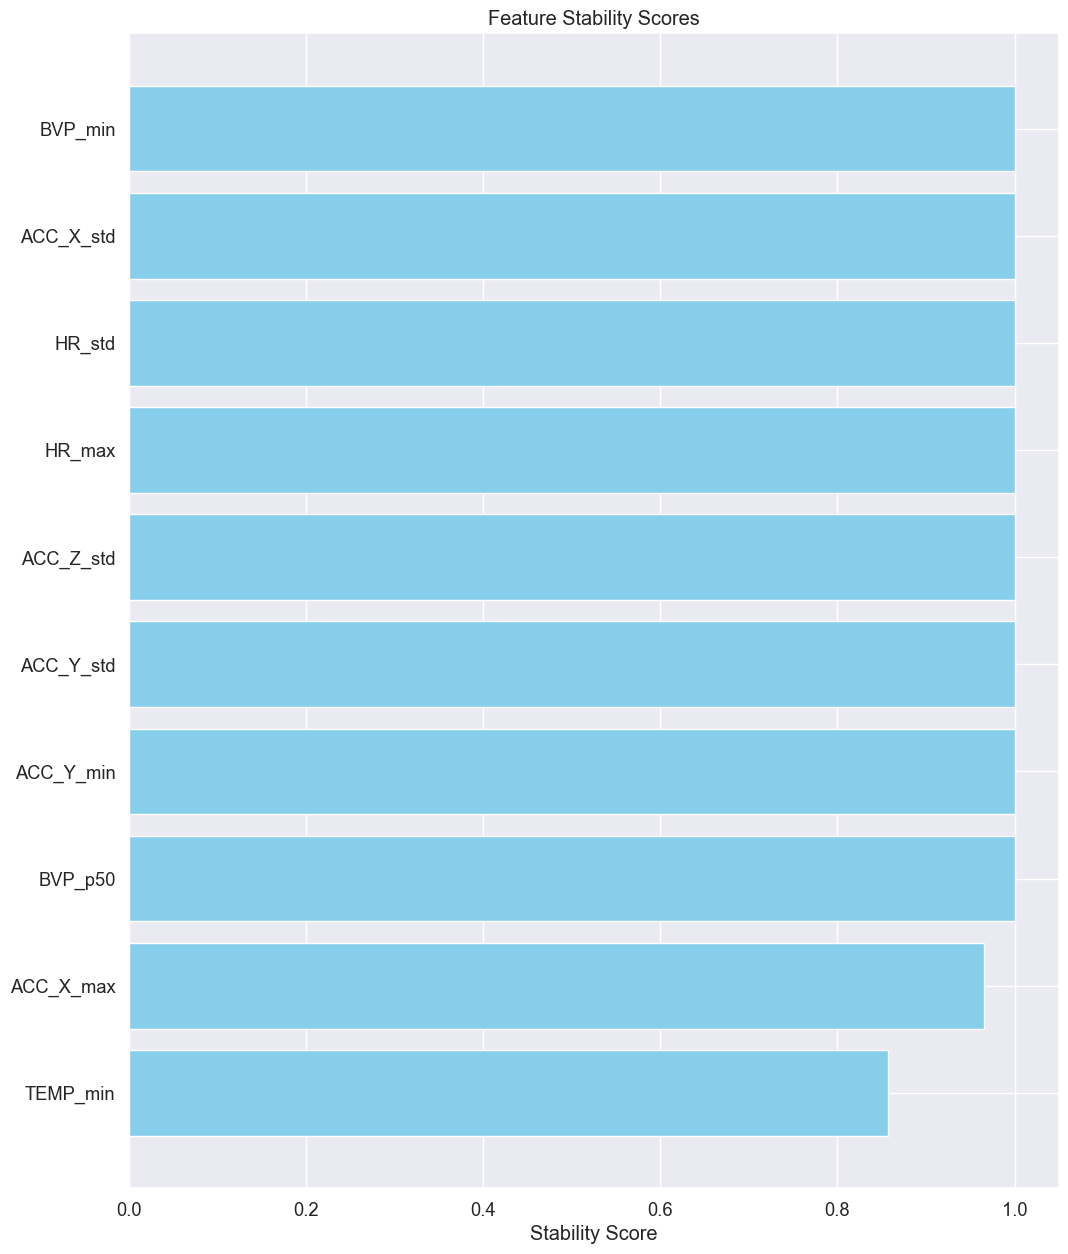

In [58]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.01;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [59]:
# feature_importance_df[feature_importance_df.Stability_Score>0.6]
# results[0.01]
feature_importance_df.shape

(10, 2)

In [60]:
alpha=0.02;
sc=0.5;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
feature_importance_df.shape

(10, 2)